# Chapter 11 — Sparse matrices and Krylov subspace methods

**Numerical Linear Algebra: Theory, Algorithms, and Computation**

**Abdallah Alsammani, Ph.D.**  
Department of Mathematical Sciences & Data Science  
Delaware State University

Lecture notes: <https://aalsammani.github.io/numerical-linear-algebra/>  
Notes for this chapter: <https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html>  
Repository: <https://github.com/aalsammani/Numerical-Linear-Algebra-Notebooks>

This notebook is the computational laboratory of the chapter; the theory,
proofs and exercises are in the lecture notes, to which the links below
point. References such as Trefethen and Bau (1997) are listed in the
[bibliography of the notes](https://aalsammani.github.io/numerical-linear-algebra/back/bibliography.html). Version
1.0, September 2026.

---

This notebook accompanies [Chapter 11](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11) of the notes. It builds
the basic tools of large-scale linear algebra from scratch, checks each one
against SciPy, and measures how the convergence of iterative methods depends
on the spectrum of the matrix.

**Learning objectives.** After working through this lab you should be able to

1. store a sparse matrix in CSR format, implement the CSR matrix-vector
   product, and build the 2D model Poisson matrix with Kronecker products;
2. implement the Jacobi and Gauss-Seidel iterations and predict their
   convergence rate from the spectral radius of the iteration matrix;
3. implement the Arnoldi and Lanczos processes, verify the Arnoldi relation,
   and observe the loss of orthogonality of Lanczos in floating point;
4. implement GMRES with Givens rotations and conjugate gradients, and compare
   them with `scipy.sparse.linalg.gmres` and `scipy.sparse.linalg.cg`;
5. compare observed CG convergence with the Chebyshev bound, and measure the
   effect of restarting and of preconditioning on iteration counts;
6. compute a few extreme eigenvalues of a large sparse matrix with `eigsh`.

Run the cells in order from a fresh kernel. All timings are observations on
the machine that executed the notebook.

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.linalg as sla
import scipy.sparse as sp
import scipy.sparse.linalg as spla

rng = np.random.default_rng(20261111)
u = np.finfo(float).eps / 2          # unit roundoff of IEEE double precision, 2**-53
plt.rcParams.update({"figure.figsize": (6.4, 4.0), "axes.grid": True, "grid.alpha": 0.3})
print(f"NumPy {np.__version__}, SciPy {scipy.__version__}; unit roundoff u = {u:.3e}")

NumPy 2.5.3, SciPy 1.18.1; unit roundoff u = 1.110e-16


## 1. Sparse storage and the CSR matrix-vector product

The small matrix of [Example 11.2](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-exa-formats) has 7 nonzeros. In the
*compressed sparse row* (CSR) format the nonzeros are stored row by row in
`data`, their column indices in `indices`, and `indptr[i]:indptr[i+1]` is the
range of row `i`. We build it by hand and compare with SciPy's conversion.

In [2]:
A_small = np.array([[5.0, 0, 0, 1],
                    [0, 8, 0, 0],
                    [2, 0, 3, 0],
                    [0, 4, 0, 7]])
data = np.array([5.0, 1, 8, 2, 3, 4, 7])
indices = np.array([0, 3, 1, 0, 2, 1, 3])
indptr = np.array([0, 2, 3, 5, 7])

S = sp.csr_array(A_small)
print("SciPy CSR: data", S.data, " indices", S.indices, " indptr", S.indptr)
assert np.array_equal(S.data, data) and np.array_equal(S.indices, indices) and np.array_equal(S.indptr, indptr)

C = sp.csc_array(A_small)
print("SciPy CSC: data", C.data, " row indices", C.indices, " indptr", C.indptr)
Z = sp.coo_array(A_small)
print("COO: rows", Z.coords[0], " cols", Z.coords[1], " data", Z.data)

SciPy CSR: data [5. 1. 8. 2. 3. 4. 7.]  indices [0 3 1 0 2 1 3]  indptr [0 2 3 5 7]
SciPy CSC: data [5. 2. 8. 4. 3. 1. 7.]  row indices [0 2 1 3 2 0 3]  indptr [0 2 4 5 7]
COO: rows [0 0 1 2 2 3 3]  cols [0 3 1 0 2 1 3]  data [5. 1. 8. 2. 3. 4. 7.]


[Algorithm 11.1](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-alg-csr-matvec) computes $y = Ax$ one row at a time: each
stored entry contributes one multiplication and one addition, so the cost is
$2\,\mathrm{nnz}(A)$ flops. We write it with explicit loops (slow in Python,
but a literal transcription of the algorithm) and in a vectorized form that
uses `np.add.reduceat` to sum the products row by row.

In [3]:
def csr_matvec(data, indices, indptr, x):
    """y = A x for A in CSR format: a literal transcription of the algorithm."""
    n = len(indptr) - 1
    y = np.zeros(n)
    for i in range(n):
        s = 0.0
        for p in range(indptr[i], indptr[i + 1]):
            s += data[p] * x[indices[p]]
        y[i] = s
    return y


def csr_matvec_vectorized(data, indices, indptr, x):
    """Same product: form all products data[p] * x[indices[p]], then sum each row's segment."""
    prod = data * x[indices]
    y = np.zeros(len(indptr) - 1)
    nonempty = indptr[:-1] < indptr[1:]
    y[nonempty] = np.add.reduceat(prod, indptr[:-1][nonempty])
    return y


x = np.array([1.0, 2.0, 3.0, 4.0])
print("loop:", csr_matvec(data, indices, indptr, x), " vectorized:",
      csr_matvec_vectorized(data, indices, indptr, x), " dense:", A_small @ x)
assert np.array_equal(csr_matvec(data, indices, indptr, x), A_small @ x)   # small integers: exact

loop: [ 9. 16. 11. 36.]  vectorized: [ 9. 16. 11. 36.]  dense: [ 9. 16. 11. 36.]


## 2. The model problem via Kronecker products

The 1D matrix $T_N = \operatorname{tridiag}(-1, 2, -1)$ and the 2D matrix
$A = I\otimes T_N + T_N\otimes I$ of order $n = N^2$ are the discrete
Laplacians of [Section 11.1](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-sec-large) (without the factor $1/h^2$).

In [4]:
def laplacian_1d(N):
    return sp.diags([-1.0, 2.0, -1.0], [-1, 0, 1], shape=(N, N), format="csr")


def poisson_2d(N):
    T = laplacian_1d(N)
    I = sp.identity(N, format="csr")
    return (sp.kron(I, T, format="csr") + sp.kron(T, I, format="csr")).tocsr()


N = 100
A = poisson_2d(N)
n = A.shape[0]
print(f"n = {n}, nnz = {A.nnz} ({A.nnz / n:.2f} per row)")
dense_bytes = 8 * n * n
csr_bytes = A.data.nbytes + A.indices.nbytes + A.indptr.nbytes
print(f"dense storage {dense_bytes / 1e6:.0f} MB, CSR storage {csr_bytes / 1e6:.2f} MB")

x = rng.standard_normal(n)
y_ref = A @ x
y_vec = csr_matvec_vectorized(A.data, A.indices, A.indptr, x)
# Each entry of y is a sum of at most 5 products: |y - y_ref| <= 2*gamma_5 |A||x| (two summation orders).
gamma5 = 5 * u / (1 - 5 * u)
assert np.all(np.abs(y_vec - y_ref) <= 2 * gamma5 * (abs(A) @ np.abs(x)))
print("vectorized CSR product agrees with SciPy within 2*gamma_5 |A||x|")

n = 10000, nnz = 49600 (4.96 per row)
dense storage 800 MB, CSR storage 0.64 MB
vectorized CSR product agrees with SciPy within 2*gamma_5 |A||x|


**Timing the product.** The loop version is interpreted Python; SciPy's
product is compiled. Both perform $2\,\mathrm{nnz}$ flops. We time them on a
smaller grid (median of repeats, one machine).

In [5]:
def median_time(f, repeats=5):
    f()
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        f()
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


A30 = poisson_2d(30)
x30 = rng.standard_normal(A30.shape[0])
t_loop = median_time(lambda: csr_matvec(A30.data, A30.indices, A30.indptr, x30), repeats=3)
t_vec = median_time(lambda: csr_matvec_vectorized(A30.data, A30.indices, A30.indptr, x30))
t_scipy = median_time(lambda: A30 @ x30, repeats=20)
print(f"n = {A30.shape[0]}: loop {t_loop * 1e3:.2f} ms, vectorized {t_vec * 1e3:.3f} ms, SciPy {t_scipy * 1e3:.3f} ms")

n = 900: loop 1.55 ms, vectorized 0.033 ms, SciPy 0.006 ms


**Eigenvalues in closed form.** By [Theorem 11.1](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-thm-laplacian), the
eigenvalues of $T_N$ are $\lambda_j = 2 - 2\cos(j\pi h)$ with $h = 1/(N+1)$,
and those of the 2D matrix are the sums $\lambda_i + \lambda_j$. We check this
for a small grid against a dense symmetric eigensolver, whose eigenvalues
have absolute errors of order $nu\|A\|_2$.

In [6]:
Ns = 12
h = 1 / (Ns + 1)
lam1 = 2 - 2 * np.cos(np.arange(1, Ns + 1) * np.pi * h)
lam2 = np.sort((lam1[:, None] + lam1[None, :]).ravel())
computed = np.linalg.eigvalsh(poisson_2d(Ns).toarray())
print(f"max |computed - formula| = {np.max(np.abs(computed - lam2)):.1e}")
assert np.max(np.abs(computed - lam2)) < 10 * Ns**2 * u * 8     # ||A||_2 < 8

kappa_formula = 1 / np.tan(np.pi * h / 2) ** 2
print(f"kappa_2 = {computed[-1] / computed[0]:.4f}, cot^2(pi h / 2) = {kappa_formula:.4f}, "
      f"4/(pi h)^2 = {4 / (np.pi * h) ** 2:.4f}")

max |computed - formula| = 9.8e-15
kappa_2 = 67.8274, cot^2(pi h / 2) = 67.8274, 4/(pi h)^2 = 68.4931


## 3. Stationary iterations: Jacobi and Gauss-Seidel

With the splitting $A = M - N$ the iteration $Mx^{(k+1)} = Nx^{(k)} + b$ has
error $e^{(k+1)} = Ge^{(k)}$ with $G = M^{-1}N$
([Theorem 11.2](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-thm-stationary)). Jacobi uses $M = D$, Gauss-Seidel uses
$M = D + L$ (the lower triangle of $A$ including the diagonal). For the model
problem $\rho(G_J) = \cos(\pi h)$ and $\rho(G_{GS}) = \cos^2(\pi h)$.

rho(G_J)  = 0.980785,  cos(pi h)   = 0.980785


rho(G_GS) = 0.961940,  cos^2(pi h) = 0.961940
observed rates: Jacobi 0.980785, Gauss-Seidel 0.961940


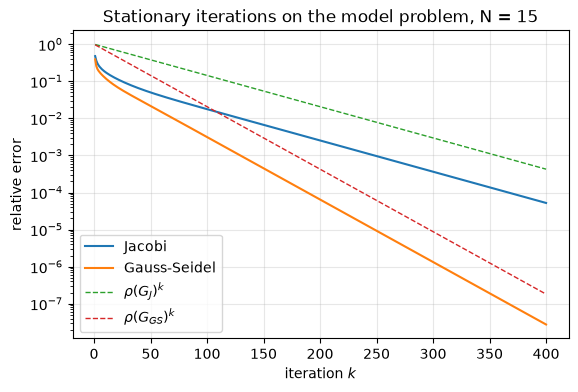

In [7]:
def jacobi(A, b, x0, iters):
    d = A.diagonal()
    x = x0.copy()
    hist = []
    for _ in range(iters):
        x = x + (b - A @ x) / d
        hist.append(x.copy())
    return hist


def gauss_seidel(A, b, x0, iters):
    DL = sp.tril(A, format="csr")          # M = D + L
    U = sp.triu(A, k=1, format="csr")      # N = -U
    x = x0.copy()
    hist = []
    for _ in range(iters):
        x = spla.spsolve_triangular(DL, b - U @ x, lower=True)
        hist.append(x.copy())
    return hist


Ns = 15
As = poisson_2d(Ns)
ns = As.shape[0]
h = 1 / (Ns + 1)
x_true = rng.standard_normal(ns)
b = As @ x_true
iters = 400
err_j = [np.linalg.norm(x - x_true) for x in jacobi(As, b, np.zeros(ns), iters)]
err_gs = [np.linalg.norm(x - x_true) for x in gauss_seidel(As, b, np.zeros(ns), iters)]

# Spectral radii computed from the dense iteration matrices
Ad = As.toarray()
G_J = np.eye(ns) - Ad / np.diag(Ad)[:, None]
G_GS = np.linalg.solve(np.tril(Ad), -np.triu(Ad, 1))
rho_J = np.max(np.abs(np.linalg.eigvals(G_J)))
rho_GS = np.max(np.abs(np.linalg.eigvals(G_GS)))
print(f"rho(G_J)  = {rho_J:.6f},  cos(pi h)   = {np.cos(np.pi * h):.6f}")
print(f"rho(G_GS) = {rho_GS:.6f},  cos^2(pi h) = {np.cos(np.pi * h) ** 2:.6f}")
# Observed asymptotic rate: geometric mean of the error reduction over the last 100 steps
rate_j = (err_j[-1] / err_j[-101]) ** (1 / 100)
rate_gs = (err_gs[-1] / err_gs[-101]) ** (1 / 100)
print(f"observed rates: Jacobi {rate_j:.6f}, Gauss-Seidel {rate_gs:.6f}")
assert abs(rho_J - np.cos(np.pi * h)) < 1e-8 and abs(rate_j - rho_J) < 1e-3
# The eigenvalues of G_GS are computed from a nonnormal matrix; agreement to 1e-6 is ample here.
assert abs(rho_GS - np.cos(np.pi * h) ** 2) < 1e-6 and abs(rate_gs - rho_GS) < 1e-3

fig, ax = plt.subplots()
k = np.arange(1, iters + 1)
ax.semilogy(k, np.array(err_j) / np.linalg.norm(x_true), label="Jacobi")
ax.semilogy(k, np.array(err_gs) / np.linalg.norm(x_true), label="Gauss-Seidel")
ax.semilogy(k, rho_J**k, "--", lw=1, label=r"$\rho(G_J)^k$")
ax.semilogy(k, rho_GS**k, "--", lw=1, label=r"$\rho(G_{GS})^k$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel("relative error")
ax.set_title(f"Stationary iterations on the model problem, N = {Ns}")
ax.legend()
plt.show()

**Interpretation.** After a short transient in which the high-frequency error
components are damped, both errors decrease by the factor $\rho(G)$ per step,
and Gauss-Seidel is twice as fast as Jacobi in the sense that
$\rho(G_{GS}) = \rho(G_J)^2$. Both rates approach 1 like $1 - \mathcal{O}(h^2)$
as the grid is refined, which is why these methods are rarely used as
solvers on their own (they survive as smoothers in multigrid and as
preconditioners).

**The spectral radius, not symmetry or positive definiteness, decides.** The
matrix below is symmetric positive definite, so Gauss-Seidel converges
([Exercise 11.4](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-ex-gauss-seidel-spd)), but $\rho(G_J) = 1.8 > 1$ and Jacobi
diverges.

In [8]:
B3 = np.array([[1.0, 0.9, 0.9], [0.9, 1.0, 0.9], [0.9, 0.9, 1.0]])
print("eigenvalues of B3:", np.linalg.eigvalsh(B3))
GJ3 = np.eye(3) - B3 / np.diag(B3)[:, None]
GGS3 = np.linalg.solve(np.tril(B3), -np.triu(B3, 1))
print(f"rho(G_J) = {np.max(np.abs(np.linalg.eigvals(GJ3))):.3f}, rho(G_GS) = {np.max(np.abs(np.linalg.eigvals(GGS3))):.3f}")
b3 = B3 @ np.ones(3)
xj = jacobi(sp.csr_array(B3), b3, np.zeros(3), 30)[-1]
xg = gauss_seidel(sp.csr_array(B3), b3, np.zeros(3), 30)[-1]
print(f"after 30 steps: Jacobi error {np.linalg.norm(xj - 1):.2e}, Gauss-Seidel error {np.linalg.norm(xg - 1):.2e}")

eigenvalues of B3: [0.1 0.1 2.8]
rho(G_J) = 1.800, rho(G_GS) = 0.854
after 30 steps: Jacobi error 7.88e+07, Gauss-Seidel error 2.18e-02


## 4. The Arnoldi process

[Algorithm 11.2](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-alg-arnoldi) builds an orthonormal basis $q_1,\dots,q_{k+1}$ of
the Krylov space $\mathcal{K}_{k+1}(A, b)$ with modified Gram-Schmidt and
returns the $(k+1)\times k$ Hessenberg matrix $\tilde H_k$ with
$AQ_k = Q_{k+1}\tilde H_k$.

In [9]:
def arnoldi(A, b, k):
    """Arnoldi with modified Gram-Schmidt. Returns Q (n x (j+1)) and H ((j+1) x j),
    where j = k unless an invariant subspace is found earlier (breakdown)."""
    n = b.size
    Q = np.zeros((n, k + 1))
    H = np.zeros((k + 1, k))
    Q[:, 0] = b / np.linalg.norm(b)
    for j in range(k):
        w = A @ Q[:, j]
        norm_Aq = np.linalg.norm(w)
        for i in range(j + 1):                 # modified Gram-Schmidt
            H[i, j] = Q[:, i] @ w
            w = w - H[i, j] * Q[:, i]
        H[j + 1, j] = np.linalg.norm(w)
        # Breakdown: K_{j+1} is invariant under A. In floating point h_{j+1,j} is then
        # not exactly zero but of the order of rounding errors, n u ||A q_j||.
        if H[j + 1, j] <= 10 * n * u * norm_Aq:
            return Q[:, : j + 1], H[: j + 1, : j + 1]
        Q[:, j + 1] = w / H[j + 1, j]
    return Q, H

**Worked example.** For $A = \operatorname{diag}(1,2,3)$ and $b = (1,1,1)^T$,
[Example 11.5](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-exa-arnoldi) computes by hand
$\tilde H_2 = \begin{bmatrix}2&\sqrt{2/3}\\ \sqrt{2/3}&2\\ 0&1/\sqrt3\end{bmatrix}$.
The third step breaks down, because $\mathcal{K}_3$ is all of $\mathbb{R}^3$,
and the $3\times3$ matrix $H_3$ has the eigenvalues $1, 2, 3$ of $A$.

In [10]:
Q3, H3 = arnoldi(np.diag([1.0, 2.0, 3.0]), np.ones(3), 3)
print(np.round(H3, 6))
H_hand = np.array([[2, np.sqrt(2 / 3), 0], [np.sqrt(2 / 3), 2, 1 / np.sqrt(3)], [0, 1 / np.sqrt(3), 2]])
assert np.allclose(H3, H_hand, atol=10 * u * 3)
print("eigenvalues of H_2:", np.linalg.eigvalsh(H3[:2, :2]), " eigenvalues of H_3:", np.linalg.eigvalsh(H3))

[[2.       0.816497 0.      ]
 [0.816497 2.       0.57735 ]
 [0.       0.57735  2.      ]]
eigenvalues of H_2: [1.18350342 2.81649658]  eigenvalues of H_3: [1. 2. 3.]


**Verification on a larger nonsymmetric matrix.** In floating point the
Arnoldi relation holds to working accuracy, with a residual of order
$k\,n\,u\|A\|$ at most. Orthogonality is a different matter: modified
Gram-Schmidt does not guarantee it, and the loss grows as the Krylov basis
becomes more ill-conditioned, which happens as Ritz vectors converge. Running
the orthogonalization loop twice ("reorthogonalization") restores
orthogonality to working accuracy at twice the cost.

In [11]:
def arnoldi_reorth(A, b, k):
    """Arnoldi with MGS applied twice in every step (no breakdown handling)."""
    n = b.size
    Q = np.zeros((n, k + 1))
    H = np.zeros((k + 1, k))
    Q[:, 0] = b / np.linalg.norm(b)
    for j in range(k):
        w = A @ Q[:, j]
        for _ in range(2):
            for i in range(j + 1):
                c = Q[:, i] @ w
                H[i, j] += c
                w = w - c * Q[:, i]
        H[j + 1, j] = np.linalg.norm(w)
        Q[:, j + 1] = w / H[j + 1, j]
    return Q, H


n_a = 400
A_ns = sp.random_array((n_a, n_a), density=0.02, rng=rng, format="csr") + sp.diags(np.linspace(1, 10, n_a))
b_a = rng.standard_normal(n_a)
normA = spla.norm(A_ns, 1)                            # ||A||_1, a cheap measure of the scale of A
print(f"{'k':>4} {'Arnoldi relation':>17} {'||I-Q^TQ|| (MGS)':>17} {'||I-Q^TQ|| (MGS twice)':>23}")
for k in (10, 20, 30, 40, 60):
    Q, H = arnoldi(A_ns, b_a, k)
    Q2, H2 = arnoldi_reorth(A_ns, b_a, k)
    rel = np.linalg.norm(A_ns @ Q[:, :k] - Q @ H) / normA
    orth = np.linalg.norm(Q.T @ Q - np.eye(k + 1), 2)
    orth2 = np.linalg.norm(Q2.T @ Q2 - np.eye(k + 1), 2)
    print(f"{k:4d} {rel:17.1e} {orth:17.1e} {orth2:23.1e}")
    assert rel < k * n_a * u                          # Arnoldi relation to working accuracy
    assert orth2 < 10 * k * u                         # reorthogonalized basis: orthonormal to O(k u)
    assert np.allclose(np.tril(H, -2), 0)             # upper Hessenberg

   k  Arnoldi relation  ||I-Q^TQ|| (MGS)  ||I-Q^TQ|| (MGS twice)
  10           1.6e-16           2.0e-14                 6.5e-16
  20           2.7e-16           4.7e-13                 6.6e-16
  30           3.8e-16           2.5e-11                 7.6e-16
  40           5.1e-16           1.9e-09                 7.7e-16
  60           7.6e-16           2.4e-05                 7.9e-16


The Ritz values, the eigenvalues of the square matrix $H_k$, approximate
eigenvalues of $A$, the outermost ones first. We compare the three Ritz values
of largest modulus with the eigenvalues of $A$ of largest modulus.

In [12]:
Q, H = arnoldi_reorth(A_ns, b_a, 60)
ritz = np.linalg.eigvals(H[:60, :60])
eig_A = np.linalg.eigvals(A_ns.toarray())
top_ritz = ritz[np.argsort(-np.abs(ritz))[:3]]
top_eig = eig_A[np.argsort(-np.abs(eig_A))[:3]]
print("largest Ritz values :", np.round(top_ritz, 8))
print("largest eigenvalues :", np.round(top_eig, 8))

largest Ritz values : [11.07987428+0.j 10.32978821+0.j 10.06252907+0.j]
largest eigenvalues : [11.07987428+0.j 10.32978267+0.j 10.07700721+0.j]


## 5. Lanczos and the loss of orthogonality

For symmetric $A$ the Hessenberg matrix is tridiagonal and Arnoldi reduces to
the three-term Lanczos recurrence ([Algorithm 11.3](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-alg-lanczos)). In floating
point the Lanczos vectors lose orthogonality, and they do so in a structured
way: orthogonality is lost in the direction of Ritz vectors that have
converged ([Figure 11.3](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-fig-lanczos)). We compare Lanczos with and without
full reorthogonalization on a diagonal matrix whose eigenvalues accumulate at
the lower end of the spectrum.

In [13]:
def lanczos(A, q1, k, reorth=False):
    """k steps of Lanczos. Returns alpha (k), beta (k) and Q (n x (k+1))."""
    n = q1.size
    Q = np.zeros((n, k + 1))
    alpha, beta = np.zeros(k), np.zeros(k)
    Q[:, 0] = q1 / np.linalg.norm(q1)
    for j in range(k):
        w = A @ Q[:, j]
        if j > 0:
            w -= beta[j - 1] * Q[:, j - 1]
        alpha[j] = Q[:, j] @ w
        w -= alpha[j] * Q[:, j]
        if reorth:                                # Gram-Schmidt twice against all previous vectors
            for _ in range(2):
                w -= Q[:, : j + 1] @ (Q[:, : j + 1].T @ w)
        beta[j] = np.linalg.norm(w)
        Q[:, j + 1] = w / beta[j]
    return alpha, beta, Q


n_l = 48
i = np.arange(1, n_l + 1)
lam = 0.1 + (i - 1) / (n_l - 1) * (100 - 0.1) * 0.9 ** (n_l - i)
A_l = sp.diags(lam)
q1 = np.ones(n_l)
for reorth in (False, True):
    kk = 2 * n_l
    if reorth:
        kk = n_l - 1                              # with reorthogonalization at most n - 1 more vectors exist
    alpha, beta, Q = lanczos(A_l, q1, kk, reorth=reorth)
    T = np.diag(alpha) + np.diag(beta[:-1], 1) + np.diag(beta[:-1], -1)
    theta = np.linalg.eigvalsh(T)
    copies = np.sum(np.abs(theta - lam.max()) < 1e-8 * lam.max())
    orth = np.linalg.norm(Q[:, :kk].T @ Q[:, :kk] - np.eye(kk), 2)
    print(f"reorth = {reorth!s:5}: {kk} steps, ||I - Q^T Q||_2 = {orth:.1e}, "
          f"Ritz values within 1e-8 relative of lambda_max: {copies}")

reorth = False: 96 steps, ||I - Q^T Q||_2 = 4.8e+00, Ritz values within 1e-8 relative of lambda_max: 5
reorth = True : 47 steps, ||I - Q^T Q||_2 = 6.9e-16, Ritz values within 1e-8 relative of lambda_max: 1


**Interpretation.** Without reorthogonalization, after $2n$ steps the
tridiagonal matrix has *several* Ritz values equal to $\lambda_{\max}$ to
eight digits although $\lambda_{\max}$ is a simple eigenvalue: these "ghost"
copies appear each time the lost orthogonality lets the recurrence
rediscover a converged eigenvector. With full reorthogonalization the basis
stays orthonormal to working accuracy and each eigenvalue appears once, at
the price of $\mathcal{O}(nk)$ extra work per step. The paper by
Meurant and Strako\vs  (2006) explains the ghosts and shows that they do not prevent
convergence to the true eigenvalues.

## 6. GMRES from scratch

[Algorithm 11.4](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-alg-gmres) combines Arnoldi with Givens rotations that
reduce $\tilde H_k$ to upper triangular form one column at a time. The last
entry of the rotated right-hand side is the residual norm
$\|b - Ax^{(k)}\|_2$, available without forming $x^{(k)}$. The rotations use
the convention of [Chapter 1](https://aalsammani.github.io/numerical-linear-algebra/ch01-matrix-computations/notes.html#ch01):
$\begin{bmatrix}c&s\\-s&c\end{bmatrix}$ with $c = x_i/r$, $s = x_j/r$.

In [14]:
def gmres_givens(A, b, x0=None, tol=1e-10, maxiter=None):
    """Full (unrestarted) GMRES. Returns x and the residual norms ||r_0||, ||r_1||, ...
    obtained from the rotated right-hand side."""
    n = b.size
    x0 = np.zeros(n) if x0 is None else x0
    r0 = b - A @ x0
    beta = np.linalg.norm(r0)
    m = n if maxiter is None else maxiter
    Q = np.zeros((n, m + 1))
    R = np.zeros((m + 1, m))                     # H_k, overwritten by its triangular factor
    cs, sn = np.zeros(m), np.zeros(m)
    g = np.zeros(m + 1)
    g[0] = beta
    Q[:, 0] = r0 / beta
    res = [beta]
    for k in range(m):
        w = A @ Q[:, k]
        for i in range(k + 1):                   # Arnoldi step (MGS)
            R[i, k] = Q[:, i] @ w
            w -= R[i, k] * Q[:, i]
        R[k + 1, k] = np.linalg.norm(w)
        if R[k + 1, k] > 0:
            Q[:, k + 1] = w / R[k + 1, k]
        for i in range(k):                       # apply the previous rotations to the new column
            t = cs[i] * R[i, k] + sn[i] * R[i + 1, k]
            R[i + 1, k] = -sn[i] * R[i, k] + cs[i] * R[i + 1, k]
            R[i, k] = t
        r = np.hypot(R[k, k], R[k + 1, k])       # new rotation annihilates R[k+1, k]
        cs[k], sn[k] = R[k, k] / r, R[k + 1, k] / r
        R[k, k], R[k + 1, k] = r, 0.0
        g[k + 1] = -sn[k] * g[k]
        g[k] = cs[k] * g[k]
        res.append(abs(g[k + 1]))
        if abs(g[k + 1]) <= tol * np.linalg.norm(b):
            break
    y = sla.solve_triangular(R[: k + 1, : k + 1], g[: k + 1])
    return x0 + Q[:, : k + 1] @ y, np.array(res)

**A nonsymmetric test problem.** The convection-diffusion operator
$-\Delta w + \mathbf{c}\cdot\nabla w$ on the unit square, discretized with
centered differences, gives $A = I\otimes L_1 + L_1\otimes I$ with
$L_1 = T_N + \tfrac{\gamma}{2}\operatorname{tridiag}(-1, 0, 1)$, where
$\gamma = ch$ ($h^2$ times the operator). For $\gamma>0$ the matrix is
nonsymmetric and nonnormal.

In [15]:
def convection_diffusion(N, gamma):
    C = sp.diags([-1.0, 1.0], [-1, 1], shape=(N, N))
    L1 = laplacian_1d(N) + 0.5 * gamma * C
    I = sp.identity(N)
    return (sp.kron(I, L1, format="csr") + sp.kron(L1, I, format="csr")).tocsr()


Ncd = 40
A_cd = convection_diffusion(Ncd, gamma=1.0)
n_cd = A_cd.shape[0]
b_cd = A_cd @ np.ones(n_cd)
print(f"n = {n_cd}, ||A - A^T||_1 = {spla.norm(A_cd - A_cd.T, 1):.1f}")

t0 = time.perf_counter()
x_mine, res_mine = gmres_givens(A_cd, b_cd, tol=1e-10)
t_mine = time.perf_counter() - t0
true_res = np.linalg.norm(b_cd - A_cd @ x_mine)
print(f"our GMRES: {len(res_mine) - 1} iterations, estimated residual {res_mine[-1]:.2e}, "
      f"true residual {true_res:.2e}")

res_scipy = []
x_sp, info = spla.gmres(A_cd, b_cd, rtol=1e-10, atol=0.0, restart=n_cd, maxiter=1,
                        callback=lambda rk: res_scipy.append(rk), callback_type="pr_norm")
print(f"SciPy GMRES: info = {info}, {len(res_scipy)} iterations")

# Residual norms are nonincreasing (minimization over nested spaces), up to rounding.
assert np.all(np.diff(res_mine) <= 1e-12 * res_mine[0])
# The Givens estimate equals the true residual up to rounding errors of order k n u ||A|| ||x||.
assert abs(true_res - res_mine[-1]) < len(res_mine) * n_cd * u * 8 * np.linalg.norm(x_mine) + 1e-10 * np.linalg.norm(b_cd)
# Both solutions solve the well-conditioned system to about the requested accuracy.
assert np.linalg.norm(x_mine - x_sp) / np.linalg.norm(x_sp) < 1e-7

n = 1600, ||A - A^T||_1 = 4.0


our GMRES: 96 iterations, estimated residual 6.70e-10, true residual 6.70e-10


SciPy GMRES: info = 0, 96 iterations


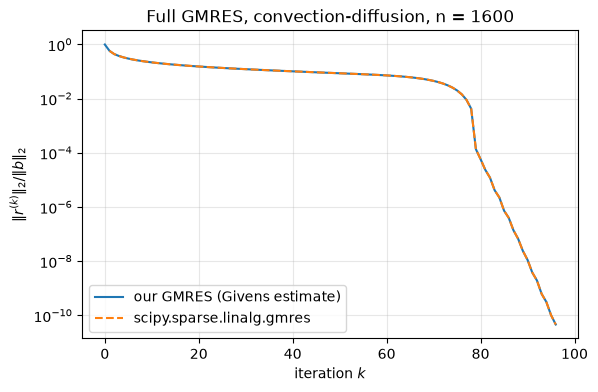

In [16]:
fig, ax = plt.subplots()
ax.semilogy(res_mine / res_mine[0], label="our GMRES (Givens estimate)")
ax.semilogy(np.arange(1, len(res_scipy) + 1), res_scipy, "--", label="scipy.sparse.linalg.gmres")
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$\|r^{(k)}\|_2 / \|b\|_2$")
ax.set_title(f"Full GMRES, convection-diffusion, n = {n_cd}")
ax.legend()
plt.show()

The two residual histories coincide: both codes compute the same minimal
residual iterates, and differences appear only at the level of rounding
errors.

**Restarting.** Full GMRES stores $k+1$ basis vectors and spends
$\mathcal{O}(nk)$ flops per step on orthogonalization. GMRES($m$) restarts
after $m$ steps with the current iterate as the new initial guess, which
bounds the cost but discards the Krylov space and can slow convergence
considerably.

In [17]:
for m in (5, 10, 20, 40, n_cd):
    count = []
    x_m, info = spla.gmres(A_cd, b_cd, rtol=1e-10, atol=0.0, restart=m, maxiter=2000,
                           callback=lambda rk: count.append(rk), callback_type="pr_norm")
    label = "full" if m == n_cd else f"GMRES({m})"
    print(f"{label:10s}: {len(count):5d} inner iterations, info = {info}, "
          f"relative residual {np.linalg.norm(b_cd - A_cd @ x_m) / np.linalg.norm(b_cd):.1e}")

GMRES(5)  :   155 inner iterations, info = 0, relative residual 3.4e-11
GMRES(10) :   208 inner iterations, info = 0, relative residual 6.5e-11


GMRES(20) :   290 inner iterations, info = 0, relative residual 9.4e-11


GMRES(40) :   381 inner iterations, info = 0, relative residual 9.8e-11
full      :    96 inner iterations, info = 0, relative residual 4.6e-11


Every restarted variant needs more matrix-vector products than full GMRES.
Perhaps surprisingly, the counts are not monotone in $m$: here GMRES(5) needs
fewer products than GMRES(40). The effect of the restart length is hard to
predict, but restarting always gives up the optimality of full GMRES.

**Complete stagnation.** For the cyclic shift matrix $Z$ ($Ze_j = e_{j+1}$,
$Ze_n = e_1$) and $b = e_1$, the residual of GMRES is $\|b\|_2$ for
$k = 0,\dots,n-1$ and $0$ at step $n$ ([Example 11.6](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-exa-shift)), so
GMRES($m$) with $m<n$ never makes progress.

In [18]:
n_z = 8
Z = sp.csr_array(np.roll(np.eye(n_z), 1, axis=0))
e1 = np.eye(n_z)[:, 0]
x_z, res_z = gmres_givens(Z, e1, tol=1e-12)
print("full GMRES residuals:", np.round(res_z, 12))
x_r, info = spla.gmres(Z, e1, rtol=1e-12, atol=0.0, restart=4, maxiter=50)
print(f"GMRES(4) after 50 cycles: residual {np.linalg.norm(e1 - Z @ x_r):.3f}, info = {info}")
assert np.allclose(res_z[:n_z], 1.0) and res_z[n_z] < 1e-12

full GMRES residuals: [1. 1. 1. 1. 1. 1. 1. 1. 0.]
GMRES(4) after 50 cycles: residual 1.000, info = 50


**Preconditioning GMRES with ILU.** `scipy.sparse.linalg.spilu` computes an
incomplete LU factorization with threshold dropping (SuperLU's ILUTP). Passed
as `M`, its solve is applied as a preconditioner.

In [19]:
for drop_tol in (1e-1, 1e-2, 1e-3):
    ilu = spla.spilu(A_cd.tocsc(), drop_tol=drop_tol, fill_factor=10)
    M = spla.LinearOperator(A_cd.shape, matvec=ilu.solve)
    count = []
    x_p, info = spla.gmres(A_cd, b_cd, rtol=1e-10, atol=0.0, restart=n_cd, maxiter=1, M=M,
                           callback=lambda rk: count.append(rk), callback_type="pr_norm")
    fill = (ilu.L.nnz + ilu.U.nnz) / A_cd.nnz
    print(f"drop_tol = {drop_tol:.0e}: nnz(L+U)/nnz(A) = {fill:.2f}, {len(count):3d} iterations, "
          f"true relative residual {np.linalg.norm(b_cd - A_cd @ x_p) / np.linalg.norm(b_cd):.1e}")
print(f"unpreconditioned: {len(res_mine) - 1} iterations")

drop_tol = 1e-01: nnz(L+U)/nnz(A) = 2.25,  19 iterations, true relative residual 2.1e-10
drop_tol = 1e-02: nnz(L+U)/nnz(A) = 3.96,   8 iterations, true relative residual 3.9e-11
drop_tol = 1e-03: nnz(L+U)/nnz(A) = 5.18,   5 iterations, true relative residual 5.3e-12
unpreconditioned: 96 iterations


A smaller drop tolerance keeps more fill, costs more to compute and apply,
and reduces the number of iterations. Note that SciPy's GMRES monitors the
*preconditioned* residual within a restart cycle, and that is also what the
callback reports; we therefore print the true residual too
([Section 11.11](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-sec-stopping)).

## 7. Conjugate gradients from scratch

[Algorithm 11.6](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-alg-pcg) with $M = I$ is plain CG. The function below accepts
a routine that applies $M^{-1}$, so it covers both cases.

In [20]:
def pcg(A, b, x0=None, tol=1e-10, maxiter=None, M_solve=None, callback=None):
    """Preconditioned conjugate gradients. Stops when ||r_k||_2 <= tol ||b||_2
    (recursively updated residual). Returns x and the list of residual norms."""
    n = b.size
    x = np.zeros(n) if x0 is None else x0.copy()
    M_solve = (lambda r: r) if M_solve is None else M_solve
    r = b - A @ x
    z = M_solve(r)
    p = z.copy()
    rz = r @ z
    res = [np.linalg.norm(r)]
    for _ in range(maxiter or 10 * n):
        if res[-1] <= tol * np.linalg.norm(b):
            break
        q = A @ p
        alpha = rz / (p @ q)
        x += alpha * p
        r -= alpha * q
        z = M_solve(r)
        rz_new = r @ z
        p = z + (rz_new / rz) * p
        rz = rz_new
        res.append(np.linalg.norm(r))
        if callback is not None:
            callback(x)
    return x, np.array(res)


N = 63
A = poisson_2d(N)
n = A.shape[0]
x_true = rng.standard_normal(n)
b = A @ x_true
errA = []
x_cg, res_cg = pcg(A, b, tol=1e-10,
                   callback=lambda xk: errA.append(np.sqrt((x_true - xk) @ (A @ (x_true - xk)))))
res_sp = []
x_ref, info = spla.cg(A, b, rtol=1e-10, atol=0.0, callback=lambda xk: res_sp.append(np.linalg.norm(b - A @ xk)))
print(f"our CG: {len(res_cg) - 1} iterations; SciPy cg: {len(res_sp)} iterations, info = {info}")
kappa = 1 / np.tan(np.pi / (2 * (N + 1))) ** 2
print(f"kappa_2(A) = {kappa:.1f}; ||x_ours - x_scipy|| / ||x|| = {np.linalg.norm(x_cg - x_ref) / np.linalg.norm(x_ref):.1e}")
# Both stop with relative residual <= 1e-10, so each forward error is at most kappa * 1e-10.
assert np.linalg.norm(x_cg - x_true) / np.linalg.norm(x_true) <= kappa * 1e-10
assert abs(len(res_cg) - 1 - len(res_sp)) <= 2
# The A-norm of the error decreases monotonically (the iterates minimize it over nested spaces).
assert np.all(np.diff(errA) <= 1e-12 * errA[0])

our CG: 198 iterations; SciPy cg: 198 iterations, info = 0
kappa_2(A) = 1659.4; ||x_ours - x_scipy|| / ||x|| = 0.0e+00


**Iterations grow like $\sqrt{\kappa}$.** For the model problem
$\kappa_2(A) = \cot^2(\pi h/2)\approx 4/(\pi h)^2$, so $\sqrt\kappa$ grows
like $N$. The Chebyshev bound [(11.11)](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#equation-ch11-eq-cg-bound) predicts that the number
of iterations for a fixed error reduction grows proportionally to $N$, while
Jacobi would need $\mathcal{O}(N^2)$ iterations.

In [21]:
print(f"{'N':>5} {'n':>7} {'sqrt(kappa)':>12} {'CG its':>7} {'bound its':>10} {'Jacobi its (predicted)':>23}")
for N in (15, 31, 63, 127):
    A = poisson_2d(N)
    n = A.shape[0]
    b = A @ rng.standard_normal(n)
    its = []
    spla.cg(A, b, rtol=1e-8, atol=0.0, callback=lambda xk: its.append(1))
    kap = 1 / np.tan(np.pi / (2 * (N + 1))) ** 2
    bound_its = np.log(1e-8 / 2) / np.log((np.sqrt(kap) - 1) / (np.sqrt(kap) + 1))
    jac_its = np.log(1e-8) / np.log(np.cos(np.pi / (N + 1)))
    print(f"{N:5d} {n:7d} {np.sqrt(kap):12.1f} {len(its):7d} {bound_its:10.0f} {jac_its:23.0f}")

    N       n  sqrt(kappa)  CG its  bound its  Jacobi its (predicted)
   15     225         10.2      47         97                     949
   31     961         20.4      91        194                    3816
   63    3969         40.7     172        389                   15283


  127   16129         81.5     308        779                   61152


The observed counts roughly double when $N$ doubles, as predicted, and stay
below the bound. (The bound is for the $A$-norm of the error and the stopping
test is on the residual, so the comparison is indicative rather than exact.)

**Observed convergence versus the bound for several $\kappa$.** We run CG on
diagonal matrices with $1000$ equally spaced eigenvalues in $[1,\kappa]$ and
compare the $A$-norm error with $2\big((\sqrt\kappa-1)/(\sqrt\kappa+1)\big)^k$
([Figure 11.4](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-fig-cg-bound) in the notes shows the same experiment).

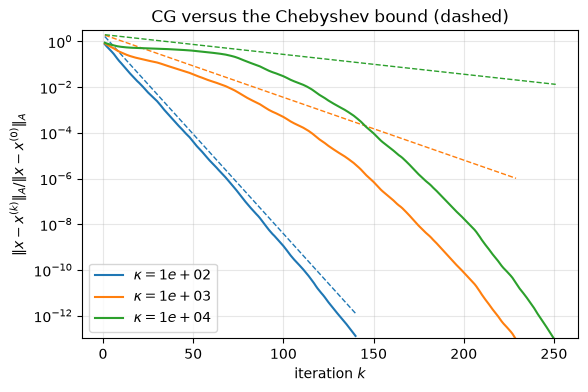

In [22]:
b_d = rng.standard_normal(1000)
fig, ax = plt.subplots()
for kap in (1e2, 1e3, 1e4):
    lam = np.linspace(1, kap, 1000)
    Ad = sp.diags(lam)
    xt = b_d / lam
    e0 = np.sqrt(xt @ (lam * xt))
    hist = []
    pcg(Ad, b_d, tol=1e-13, maxiter=400,
        callback=lambda xk: hist.append(np.sqrt((xt - xk) @ (lam * (xt - xk))) / e0))
    kk = np.arange(1, len(hist) + 1)
    q = (np.sqrt(kap) - 1) / (np.sqrt(kap) + 1)
    assert np.all(np.array(hist) <= 2 * q**kk * (1 + 1e-8))     # the bound holds at every step
    line, = ax.semilogy(kk, hist, label=rf"$\kappa = {kap:.0e}$")
    ax.semilogy(kk, 2 * q**kk, "--", color=line.get_color(), lw=1)
ax.set_ylim(1e-13, 3)
ax.set_xlabel("iteration $k$")
ax.set_ylabel(r"$\|x - x^{(k)}\|_A / \|x - x^{(0)}\|_A$")
ax.set_title("CG versus the Chebyshev bound (dashed)")
ax.legend()
plt.show()

The bound captures the initial rate for equally spaced eigenvalues, but CG
then accelerates: this is the *superlinear convergence* discussed in
[Section 11.8](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-sec-cg), caused by the Ritz values converging to the extreme
eigenvalues, after which CG behaves as if those eigenvalues had been removed.

## 8. Preconditioned CG

We implement the zero-fill incomplete Cholesky factorization IC(0): $L$ has
the sparsity pattern of the lower triangle of $A$, and $LL^T$ agrees with $A$
on that pattern. The row-oriented loop below computes
$\ell_{ij} = (a_{ij} - \sum_{k<j}\ell_{ik}\ell_{jk})/\ell_{jj}$ with the sum
restricted to the pattern, exactly like the Cholesky factorization of
[Chapter 6](https://aalsammani.github.io/numerical-linear-algebra/ch06-cholesky/notes.html#ch06) with the fill-in discarded. An optional diagonal
shift $\alpha$ factors $A + \alpha\operatorname{diag}(A)$ instead, which is a
standard remedy when IC(0) breaks down.

In [23]:
def ic0(A, shift=0.0):
    """IC(0) of a sparse symmetric matrix. Returns L (CSR, lower triangular).
    Raises LinAlgError if a nonpositive pivot occurs."""
    Low = sp.tril(sp.csr_array(A), format="csr")
    Low.sort_indices()
    n = Low.shape[0]
    rows = []                                    # rows[i] = {j: l_ij} for j <= i
    for i in range(n):
        cols = Low.indices[Low.indptr[i]:Low.indptr[i + 1]]
        vals = Low.data[Low.indptr[i]:Low.indptr[i + 1]]
        Li = {}
        for j, a_ij in zip(cols, vals):
            Lj = rows[j] if j < i else Li
            small, big = (Li, Lj) if len(Li) <= len(Lj) else (Lj, Li)
            s = sum(v * big[k] for k, v in small.items() if k < j and k in big)
            if j < i:
                Li[j] = (a_ij - s) / rows[j][j]
            else:
                piv = a_ij * (1 + shift) - s
                if piv <= 0:
                    raise np.linalg.LinAlgError(f"IC(0) breakdown: pivot {piv:.3e} at row {i}")
                Li[i] = np.sqrt(piv)
        rows.append(Li)
    r = np.repeat(np.arange(n), [len(Li) for Li in rows])
    c = np.fromiter((j for Li in rows for j in Li), dtype=np.int64, count=len(r))
    v = np.fromiter((x for Li in rows for x in Li.values()), dtype=float, count=len(r))
    return sp.csr_array((v, (r, c)), shape=(n, n))


def ic_solver(L):
    """Return a function r -> (L L^T)^{-1} r using two sparse triangular solves."""
    Lt = L.T.tocsr()
    return lambda r: spla.spsolve_triangular(Lt, spla.spsolve_triangular(L, r, lower=True), lower=False)

**Verification.** On the pattern of $A$ the product $LL^T$ must reproduce $A$
up to rounding (each entry is a short inner product). For the model problem,
IC(0) exists without a shift because the matrix is an M-matrix
(Benzi, 2002).

In [24]:
A = poisson_2d(20)
L = ic0(A)
r_idx, c_idx = A.nonzero()
diff_on_pattern = np.max(np.abs((L @ L.T - A).toarray()[r_idx, c_idx]))
print(f"max |(L L^T - A)_ij| on the pattern of A: {diff_on_pattern:.1e}")
assert diff_on_pattern < 10 * u * 8                     # a few roundings of O(1) quantities
print(f"nnz(L) = {L.nnz} = nnz(tril(A)) = {sp.tril(A).nnz}")
Ld = np.linalg.cholesky(A.toarray())
print(f"complete Cholesky factor has {np.count_nonzero(Ld)} nonzeros")

max |(L L^T - A)_ij| on the pattern of A: 8.9e-16


nnz(L) = 1160 = nnz(tril(A)) = 1160
complete Cholesky factor has 8019 nonzeros


**Effect on iteration counts.** For the model problem the diagonal of $A$ is
constant, so the Jacobi preconditioner $M = \operatorname{diag}(A)$ only
rescales and changes nothing. IC(0) reduces the iteration count by a
constant factor, but the count still grows with $N$.

In [25]:
print(f"{'N':>5} {'CG':>5} {'Jacobi-PCG':>11} {'IC(0)-PCG':>10} {'kappa(A)':>10} {'kappa(L^-1 A L^-T)':>19}")
for N in (15, 31, 63, 127):
    A = poisson_2d(N)
    n = A.shape[0]
    b = A @ np.ones(n)
    d = A.diagonal()
    L = ic0(A)
    counts = []
    for M_solve in (None, lambda r: r / d, ic_solver(L)):
        x, res = pcg(A, b, tol=1e-8, M_solve=M_solve)
        counts.append(len(res) - 1)
    if N <= 31:
        Ld = L.toarray()
        P = sla.solve_triangular(Ld, sla.solve_triangular(Ld, A.toarray(), lower=True).T, lower=True)
        ev = np.linalg.eigvalsh((P + P.T) / 2)
        kp = f"{ev[-1] / ev[0]:.1f}"
    else:
        kp = "(not computed)"
    kap = 1 / np.tan(np.pi / (2 * (N + 1))) ** 2
    print(f"{N:5d} {counts[0]:5d} {counts[1]:11d} {counts[2]:10d} {kap:10.1f} {kp:>19}")

    N    CG  Jacobi-PCG  IC(0)-PCG   kappa(A)  kappa(L^-1 A L^-T)
   15    29          29         16      103.1                10.0


   31    60          60         29      414.3                37.5
   63   121         121         53     1659.4      (not computed)


  127   230         230         97     6639.5      (not computed)


**Where the eigenvalues go.** A good preconditioner moves the spectrum of
$M^{-1}A$ into a smaller interval bounded away from zero, as the histogram
shows for $N = 31$.

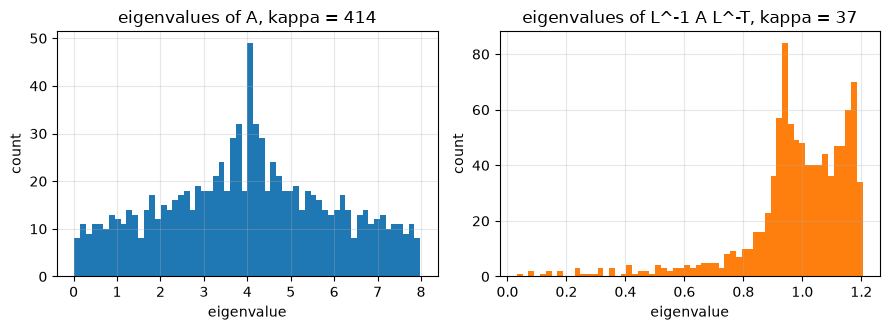

In [26]:
N = 31
A = poisson_2d(N)
Ld = ic0(A).toarray()
P = sla.solve_triangular(Ld, sla.solve_triangular(Ld, A.toarray(), lower=True).T, lower=True)
ev_A = np.linalg.eigvalsh(A.toarray())
ev_P = np.linalg.eigvalsh((P + P.T) / 2)
fig, axes = plt.subplots(1, 2, figsize=(9, 3.4))
axes[0].hist(ev_A, bins=60)
axes[0].set_title(f"eigenvalues of A, kappa = {ev_A[-1] / ev_A[0]:.0f}")
axes[1].hist(ev_P, bins=60, color="C1")
axes[1].set_title(f"eigenvalues of L^-1 A L^-T, kappa = {ev_P[-1] / ev_P[0]:.0f}")
for ax in axes:
    ax.set_xlabel("eigenvalue")
    ax.set_ylabel("count")
plt.tight_layout()
plt.show()

## 9. Krylov eigensolvers: `eigsh`

`scipy.sparse.linalg.eigsh` calls ARPACK's implicitly restarted Lanczos
method. It needs only products with $A$ (or, in shift-invert mode, solves with
$A - \sigma I$). We compute the four largest and four smallest eigenvalues of
the model problem and compare with the closed form.

In [27]:
N = 100
A = poisson_2d(N)
h = 1 / (N + 1)
lam1 = 2 - 2 * np.cos(np.arange(1, N + 1) * np.pi * h)
exact = np.sort((lam1[:, None] + lam1[None, :]).ravel())

t0 = time.perf_counter()
top = np.sort(spla.eigsh(A, k=4, which="LA", return_eigenvectors=False))
t_top = time.perf_counter() - t0
t0 = time.perf_counter()
bottom = np.sort(spla.eigsh(A, k=4, sigma=0.0, which="LM", return_eigenvectors=False))
t_bottom = time.perf_counter() - t0
print("largest :", top, "\nexact   :", exact[-4:])
print("smallest:", bottom, "\nexact   :", exact[:4])
print(f"time: largest {t_top:.2f} s, smallest (shift-invert) {t_bottom:.2f} s")
# ARPACK's default tolerance is machine precision relative to the Ritz values.
assert np.allclose(top, exact[-4:], rtol=1e-10) and np.allclose(bottom, exact[:4], rtol=1e-8)

largest : [7.99226239 7.99516376 7.99516376 7.99806513] 
exact   : [7.99226239 7.99516376 7.99516376 7.99806513]
smallest: [0.00193487 0.00483624 0.00483624 0.00773761] 
exact   : [0.00193487 0.00483624 0.00483624 0.00773761]
time: largest 0.24 s, smallest (shift-invert) 0.05 s


The gaps between the smallest eigenvalues are of order $h^2$, tiny compared
with the width of the spectrum, which makes them hard to find with plain
Lanczos; shift-invert with $\sigma = 0$
turns them into the *largest* eigenvalues $1/\lambda$ of $A^{-1}$, which are
well separated, at the price of one sparse factorization of $A$. Note the
repeated eigenvalues: $\lambda_i + \lambda_j = \lambda_j + \lambda_i$.

## 10. Stopping criteria and backward error

A relative residual $\|b - Ax^{(k)}\|_2/\|b\|_2\le\epsilon$ guarantees a
small *backward* error, but the relative forward error can be as large as
$\kappa_2(A)\,\epsilon$ ([Proposition 11.2](https://aalsammani.github.io/numerical-linear-algebra/ch11-krylov/notes.html#ch11-prop-forward-error)). We follow CG on
the model problem with $N = 63$ and compare the relative residual, the
normwise backward error
$\eta = \|r\|_2/(\|A\|_2\|x^{(k)}\|_2 + \|b\|_2)$ and the relative error.

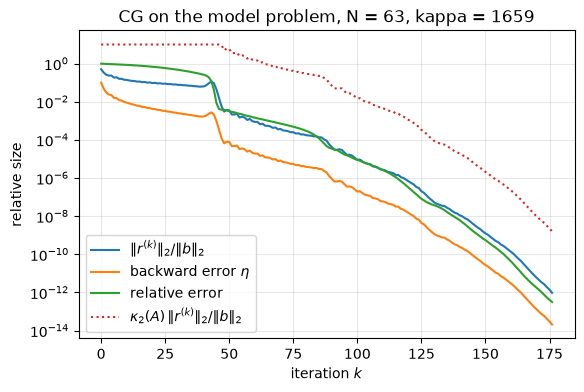

In [28]:
N = 63
A = poisson_2d(N)
n = A.shape[0]
h = 1 / (N + 1)
normA = 8 * np.cos(np.pi * h / 2) ** 2              # = lambda_max = 4 - 4 cos(N pi h)
kappa = 1 / np.tan(np.pi * h / 2) ** 2
x_true = np.sin(np.pi * np.arange(1, n + 1) / (n + 1))        # a smooth solution
b = A @ x_true
relres, eta, relerr = [], [], []

def record(xk):
    r = b - A @ xk
    relres.append(np.linalg.norm(r) / np.linalg.norm(b))
    eta.append(np.linalg.norm(r) / (normA * np.linalg.norm(xk) + np.linalg.norm(b)))
    relerr.append(np.linalg.norm(xk - x_true) / np.linalg.norm(x_true))

pcg(A, b, tol=1e-12, callback=record)
relres, eta, relerr = map(np.array, (relres, eta, relerr))
assert np.all(relerr <= kappa * relres * (1 + 1e-6))      # forward error <= kappa * relative residual
assert np.all(eta <= relres)                              # eta is never larger than ||r|| / ||b||
fig, ax = plt.subplots()
ax.semilogy(relres, label=r"$\|r^{(k)}\|_2/\|b\|_2$")
ax.semilogy(eta, label=r"backward error $\eta$")
ax.semilogy(relerr, label="relative error")
ax.semilogy(np.minimum(kappa * relres, 10), ":", label=r"$\kappa_2(A)\,\|r^{(k)}\|_2/\|b\|_2$")
ax.set_xlabel("iteration $k$")
ax.set_ylabel("relative size")
ax.set_title(f"CG on the model problem, N = {N}, kappa = {kappa:.0f}")
ax.legend()
plt.show()

The bound $\kappa_2(A)\|r\|/\|b\|$ holds but overestimates the error by a
large factor here; the relative error and the relative residual differ by
much less than $\kappa_2(A)$ because $x$ is not the worst case for the bound.

## Common mistakes

- **Building sparse matrices entry by entry in CSR format.** Changing the
  sparsity structure of a CSR matrix is expensive. Assemble in COO format (or
  with `sp.diags`, `sp.kron`, `sp.block_array`) and convert once.
- **Calling `A.toarray()` or `np.linalg.solve` on a large sparse matrix.** It
  defeats the purpose; use `spla.spsolve`, `spla.splu` or an iterative method.
- **Using `*` for matrix products with sparse matrices.** With the `sp.*_array`
  classes, `*` is elementwise; use `@`.
- **Using the wrong keyword.** Current SciPy uses `rtol` (and `atol`) in
  `cg`, `gmres`, `minres`, `bicgstab`; the old `tol` has been removed.
- **Trusting the stopping test blindly.** A small (preconditioned) residual is
  not a small error when $\kappa(A)$ is large.
- **Using a nonsymmetric preconditioner with CG.** CG requires $M$ symmetric
  positive definite; `spilu` does not in general produce one.

## Your turn

1. Implement Gauss-Seidel without `spsolve_triangular` (a loop over rows of
   the CSR matrix) and check that it reproduces the iterates above.
2. Modify `gmres_givens` into GMRES($m$) and reproduce the restarted iteration
   counts of Section 6. Try $\gamma = 1.9$ and $\gamma = 5$ and explain the
   change (the second makes the matrix lose the M-matrix property).
3. Run `lanczos` with $q_1$ a random vector on the diagonal matrix of
   Section 5 for $3n$ steps and count how many copies of $\lambda_{\max}$
   appear. Plot the Ritz values against the step number.
4. For the model problem with $N = 127$, compare the time to solve with
   `spla.spsolve`, with CG and with IC(0)-PCG, including the time to compute
   the factorization. Report medians of repeats as observations on your
   machine.

## Key takeaways

- Sparse matrices are stored with $\mathcal{O}(\mathrm{nnz})$ memory, and the
  matrix-vector product costs $2\,\mathrm{nnz}$ flops; Krylov methods need
  nothing else from $A$.
- Stationary iterations converge if and only if $\rho(M^{-1}N)<1$; on the
  model problem the rate is $1-\mathcal{O}(h^2)$, far too slow.
- Arnoldi and Lanczos build orthonormal Krylov bases; in floating point the
  Lanczos vectors lose orthogonality exactly when Ritz pairs converge.
- GMRES minimizes the residual and CG minimizes the $A$-norm of the error;
  CG's convergence is bounded in terms of $\sqrt{\kappa}$ but depends on the
  whole spectrum.
- Preconditioning changes the spectrum; the cost of building and applying
  $M$ must be weighed against the iterations saved.

## Further reading

Trefethen and Bau (1997) (Lectures 32--40), Saad (2003)
(Chapters 3, 4, 6, 7, 9 and 10), Greenbaum (1997) and
Liesen and Strako\vs  (2013); for finite-precision behavior Meurant and Strako\vs  (2006);
for preconditioners Benzi (2002).